In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import GroupShuffleSplit


import sys
sys.path.append("../..")  # Adjust the path as needed to locate utils.py

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

In [2]:
from neural_network import BasicRNN, DataFrameDataset, ToTensor
import random

hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")

Using cpu device


[2619, 456, 102, 3037, 1126]
tensor([[0.8972],
        [0.1131],
        [0.4592],
        [0.1029],
        [1.0014]]) tensor([0.8967, 0.2149, 0.4564, 0.0000, 1.0000])
[1309, 228, 51, 1518, 563]
tensor([[0.7992],
        [1.0013],
        [0.8737],
        [0.0075],
        [0.1037]]) tensor([0.8040, 1.0000, 0.8715, 0.0000, 0.1098])
[5238, 912, 204, 6074, 2253]
tensor([[0.1147],
        [0.6353],
        [0.9983],
        [0.0016],
        [0.1811]]) tensor([0.1120, 0.6323, 1.0000, 0.0000, 0.1808])
[5238, 912, 204, 2253, 2006]
tensor([[0.8044],
        [0.2695],
        [0.0053],
        [0.1923],
        [1.0082]]) tensor([0.7984, 0.2691, 0.0000, 0.2015, 1.0000])


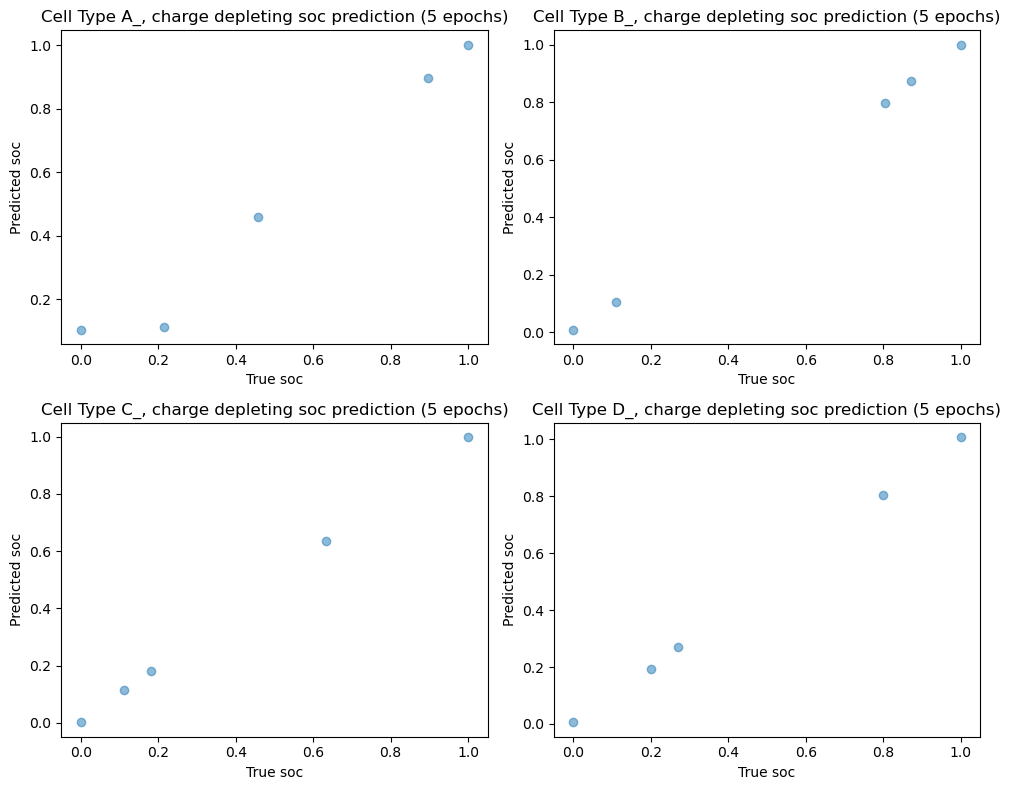

In [18]:


A_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_A_model.pth')
B_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_B_model.pth')
C_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_C_model.pth')
D_depleting_overfit = torch.load('../../results/neural_network/overfit_testing/Charge_Depleting_soc_mean_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_depleting_overfit, B_depleting_overfit, C_depleting_overfit, D_depleting_overfit
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    random.seed(42)
    overfit_idxs = random.sample(range(len(df_train)), 5)
    df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    df_test = df_train.copy().reset_index(drop=True)
    print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting soc prediction (5 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=64, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

# 64 hidden layer size

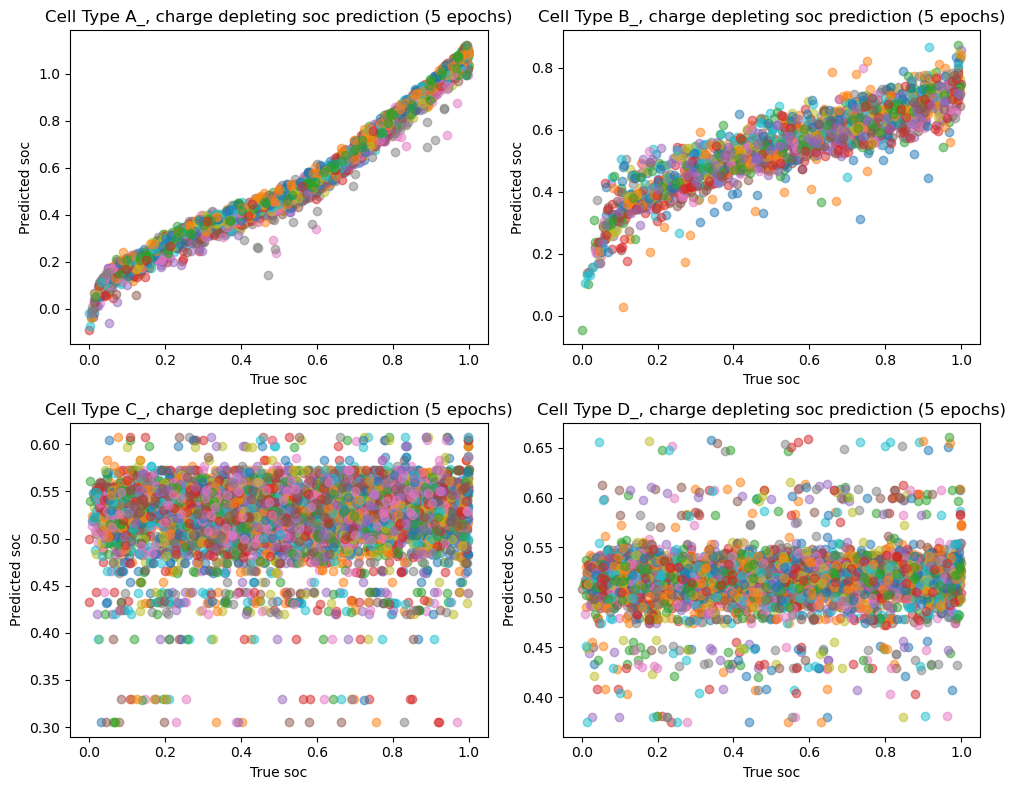

In [ ]:


A_depleting = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_A_model.pth')
B_depleting = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_B_model.pth')
C_depleting = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_C_model.pth')
D_depleting = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_depleting, B_depleting, C_depleting, D_depleting
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting soc prediction (10 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=64, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

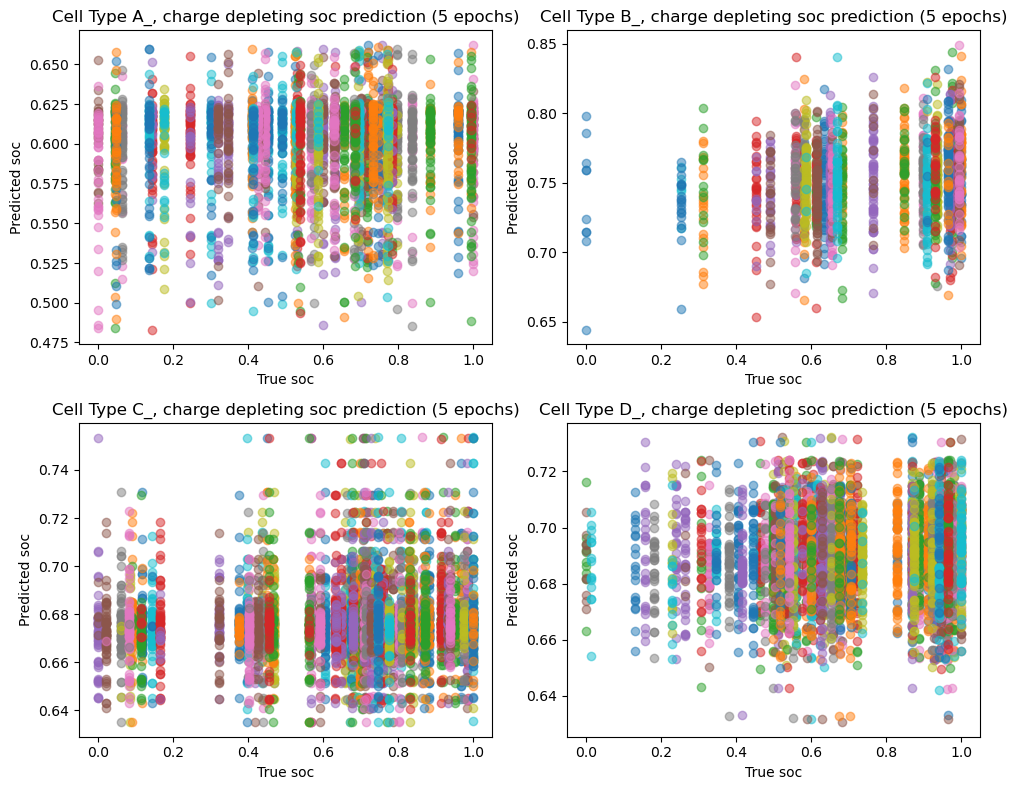

In [ ]:


A_depleting_capacity = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_A_model.pth')
B_depleting_capacity = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_B_model.pth')
C_depleting_capacity = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_C_model.pth')
D_depleting_capacity = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_depleting_capacity, B_depleting_capacity, C_depleting_capacity, D_depleting_capacity
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting soc prediction (10 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=64, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

# 128 hidden layer size

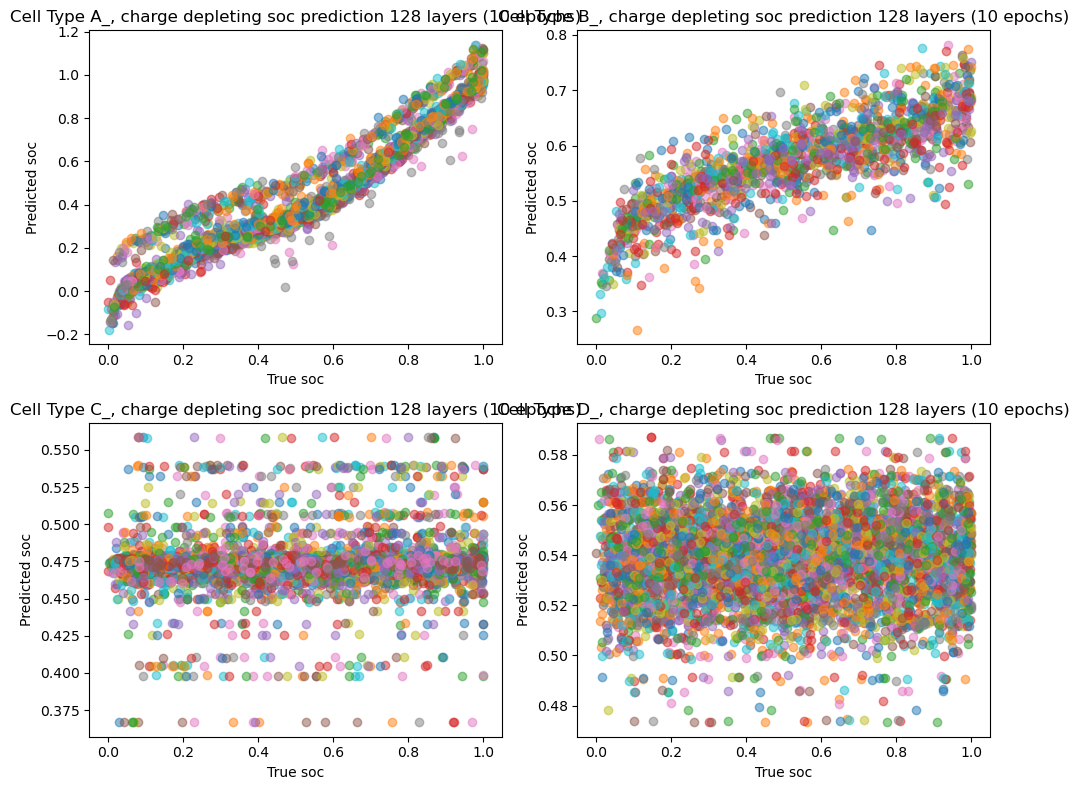

In [33]:


A_depleting_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_A_model.pth')
B_depleting_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_B_model.pth')
C_depleting_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_C_model.pth')
D_depleting_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_soc_mean_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_depleting_128, B_depleting_128, C_depleting_128, D_depleting_128
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting soc prediction 128 layers (10 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

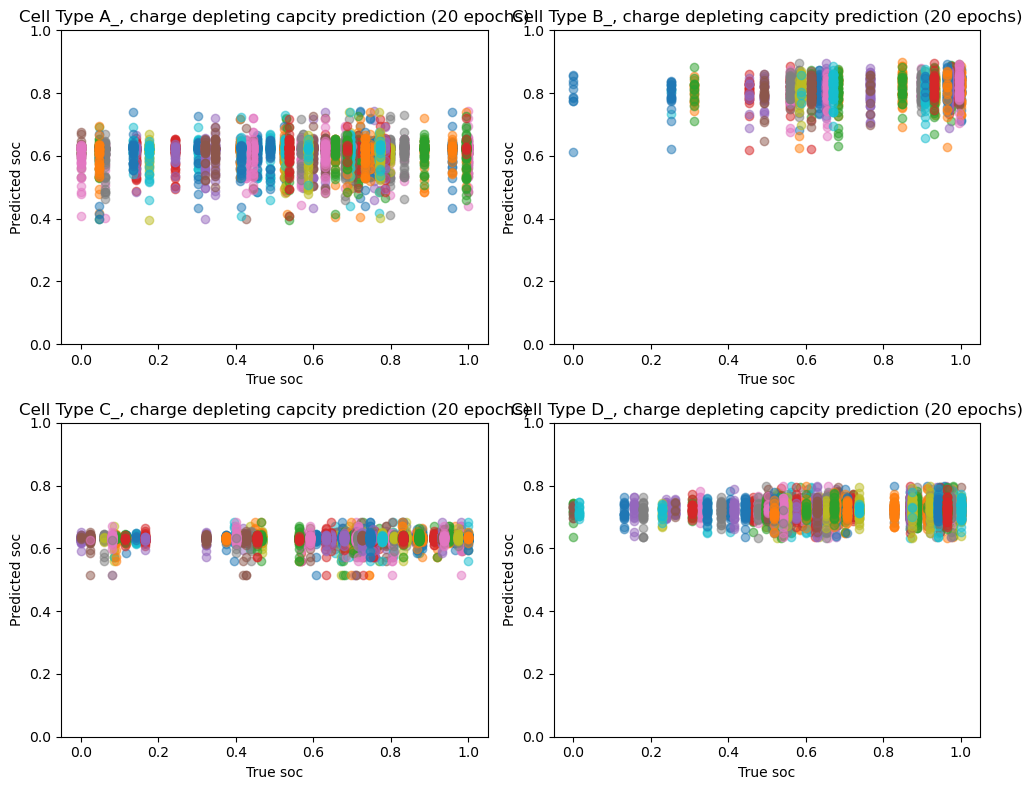

In [37]:

A_depleting_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_A_model.pth')
B_depleting_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_B_model.pth')
C_depleting_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_C_model.pth')
D_depleting_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Depleting_C3 discharge capacity_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_depleting_capacity_128, B_depleting_capacity_128, C_depleting_capacity_128, D_depleting_capacity_128
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge depleting capcity prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

RuntimeError: Error(s) in loading state_dict for BasicRNN:
	Unexpected key(s) in state_dict: "rnn.weight_ih_l1", "rnn.weight_hh_l1", "rnn.bias_ih_l1", "rnn.bias_hh_l1". 

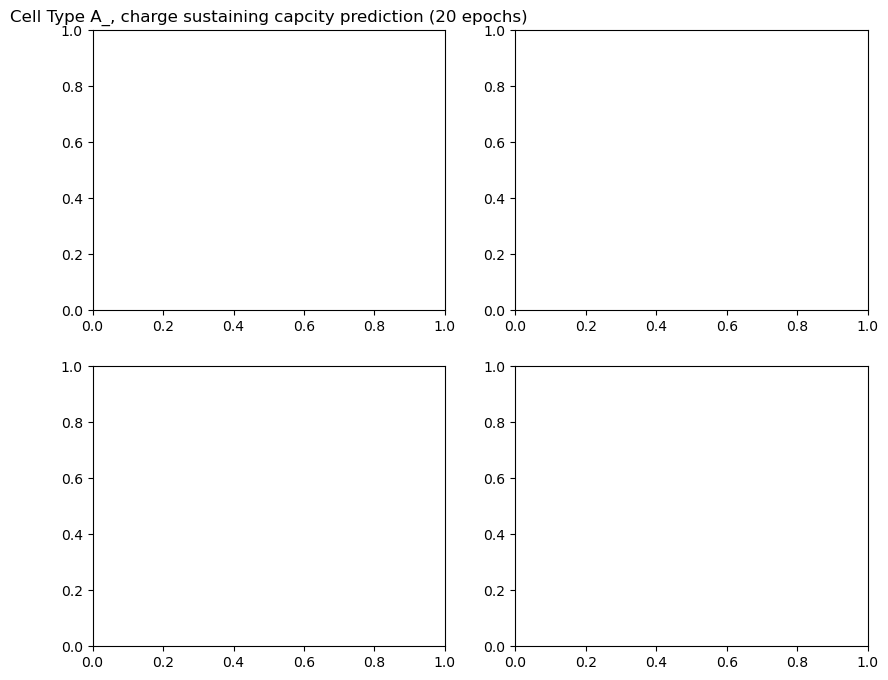

In [9]:

A_sustaining_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Sustaining_C3 discharge capacity_A_model.pth')
B_sustaining_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Sustaining_C3 discharge capacity_B_model.pth')
# C_sustaining_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Sustaining_C3 discharge capacity_C_model.pth')
# D_sustaining_capacity_128 = torch.load('../../results/neural_network/model_parameters/Charge_Sustaining_C3 discharge capacity_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
ax = ax.flatten()
df_all = hdf.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_sustaining_capacity_128, B_sustaining_capacity_128,# C_sustaining_capacity_128, D_sustaining_capacity_128
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge sustaining capcity prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity",key="Charge_Depleting", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 3, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)


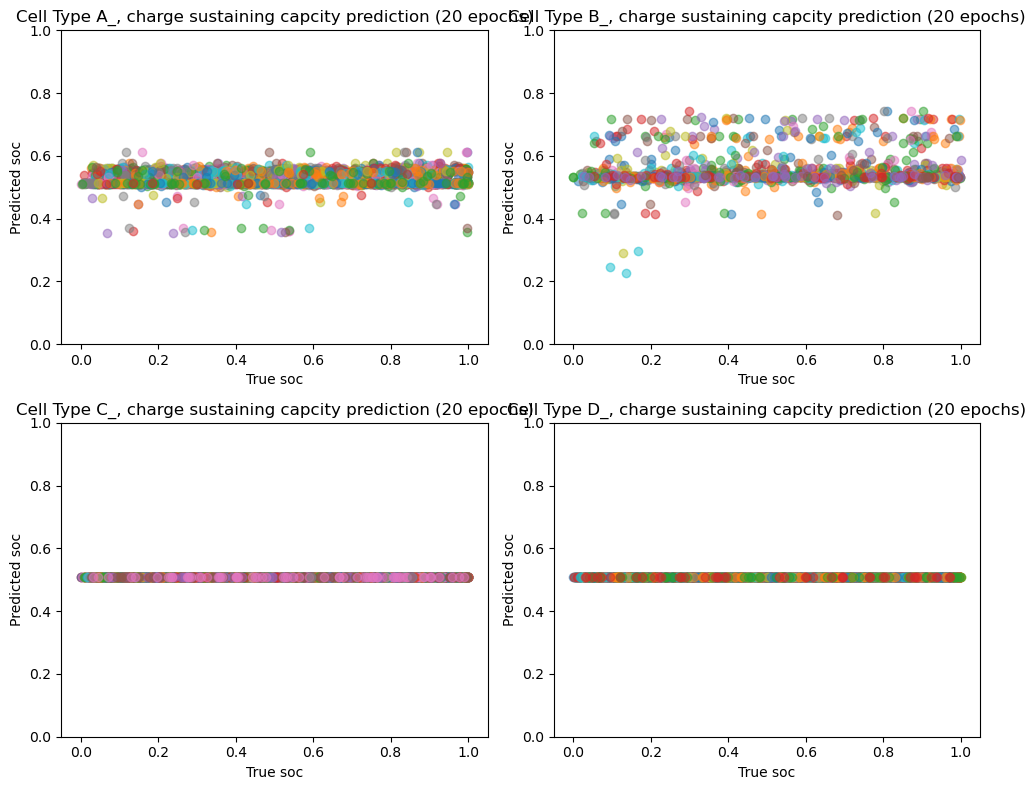

In [8]:

A_boundary_conditions = torch.load('../../results/neural_network/boundary_conditions/Charge_Depleting_soc_mean_A_model.pth')
B_boundary_conditions = torch.load('../../results/neural_network/boundary_conditions/Charge_Depleting_soc_mean_B_model.pth')
C_boundary_conditions = torch.load('../../results/neural_network/boundary_conditions/Charge_Depleting_soc_mean_C_model.pth')
D_boundary_conditions = torch.load('../../results/neural_network/boundary_conditions/Charge_Depleting_soc_mean_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
ax = ax.flatten()
hdf2 = pd.HDFStore("../../data/data_for_ml_boundary_conditions.h5", mode="r")
df_all = hdf2.get("Charge_Depleting")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_boundary_conditions, B_boundary_conditions, C_boundary_conditions, D_boundary_conditions
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    # splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    # df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    # df_train = df.iloc[idx_train].reset_index(drop=True)
    # df_test = df.iloc[idx_test].reset_index(drop=True)
    df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge sustaining capcity prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="soc_mean",key="Charge_Depleting", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 4, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            ax[i].set_xlabel("True soc")
            ax[i].set_ylabel("Predicted soc")
            ax[i].set_ylim(0, 1)
            # ax[i].draw()

fig.tight_layout()

c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will cha

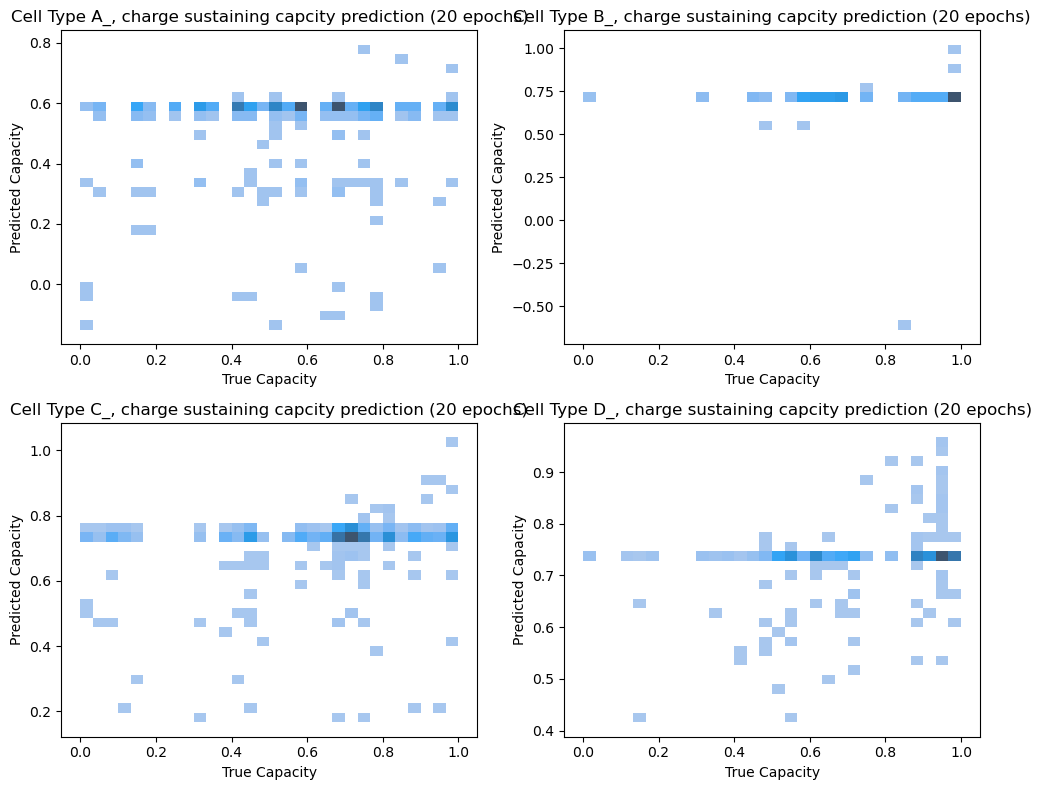

In [34]:

A_boundary_conditions_1 = torch.load('../../results/neural_network/boundary_conditions/PsRP_2_C2_C3 discharge capacity_A_model.pth')
B_boundary_conditions_1 = torch.load('../../results/neural_network/boundary_conditions/PsRP_2_C2_C3 discharge capacity_B_model.pth')
C_boundary_conditions_1 = torch.load('../../results/neural_network/boundary_conditions/PsRP_2_C2_C3 discharge capacity_C_model.pth')
D_boundary_conditions_1 = torch.load('../../results/neural_network/boundary_conditions/PsRP_2_C2_C3 discharge capacity_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
ax = ax.flatten()
hdf2 = pd.HDFStore("../../data/data_for_ml_boundary_conditions.h5", mode="r")
df_all = hdf2.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_boundary_conditions_1, B_boundary_conditions_1, C_boundary_conditions_1, D_boundary_conditions_1
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)
    # df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge sustaining capcity prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity",key="PsRP_2_C/2", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 5, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    real = []
    pred = []
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            for real_val, pred_val in zip(y.numpy(), outputs.numpy()):
                real.append(real_val)
                pred.append(pred_val[0])
            # ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            # ax[i].set_xlabel("True Capacity")
            # ax[i].set_ylabel("Predicted Capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

    sns.histplot(x=real, y=pred, ax=ax[i], bins=30)   
    ax[i].set_xlabel("True Capacity")
    ax[i].set_ylabel("Predicted Capacity")

fig.tight_layout()

c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will cha

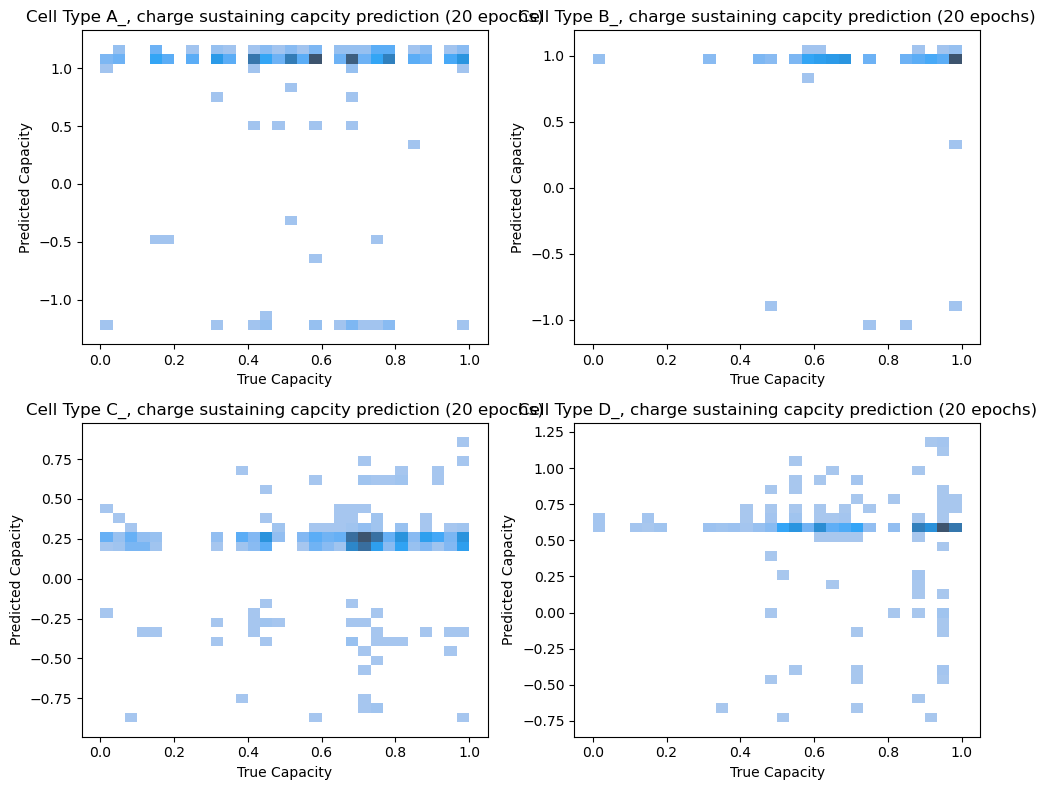

In [31]:

A_boundary_conditions_2 = torch.load('../../results/neural_network/boundary_conditions/Rate_Test_C2_C3 discharge capacity_A_model.pth')
B_boundary_conditions_2 = torch.load('../../results/neural_network/boundary_conditions/Rate_Test_C2_C3 discharge capacity_B_model.pth')
C_boundary_conditions_2 = torch.load('../../results/neural_network/boundary_conditions/Rate_Test_C2_C3 discharge capacity_C_model.pth')
D_boundary_conditions_2 = torch.load('../../results/neural_network/boundary_conditions/Rate_Test_C2_C3 discharge capacity_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
ax = ax.flatten()
hdf2 = pd.HDFStore("../../data/data_for_ml_boundary_conditions.h5", mode="r")
df_all = hdf2.get("PsRP_2_C/2")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_boundary_conditions_2, B_boundary_conditions_2, C_boundary_conditions_2, D_boundary_conditions_2
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)
    # df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge sustaining capcity prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity",key="PsRP_2_C/2", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 5, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    real = []
    pred = []
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            for real_val, pred_val in zip(y.numpy(), outputs.numpy()):
                real.append(real_val)
                pred.append(pred_val[0])
            # ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            # ax[i].set_xlabel("True Capacity")
            # ax[i].set_ylabel("Predicted Capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

    sns.histplot(x=real, y=pred, ax=ax[i], bins=30)   
    ax[i].set_xlabel("True Capacity")
    ax[i].set_ylabel("Predicted Capacity")

fig.tight_layout()

c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:109: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will cha

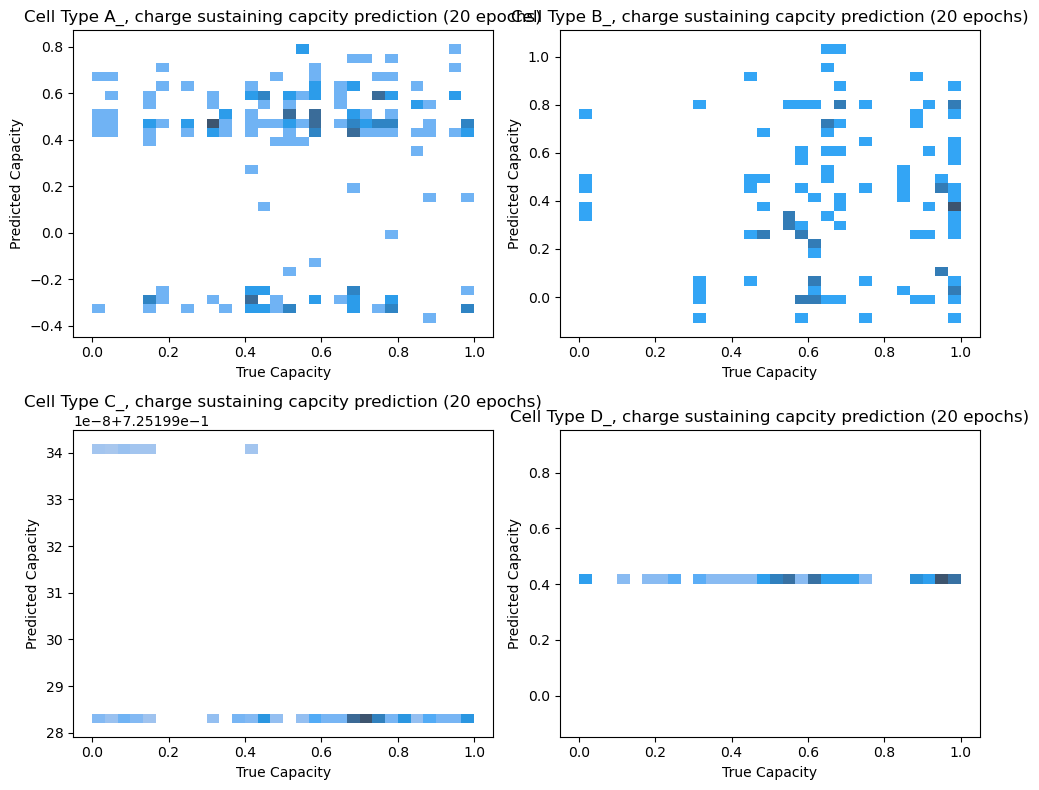

In [37]:

A_boundary_conditions_3 = torch.load('../../results/neural_network/boundary_conditions/Charge_Sustaining_C3 discharge capacity_A_model.pth')
B_boundary_conditions_3 = torch.load('../../results/neural_network/boundary_conditions/Charge_Sustaining_C3 discharge capacity_B_model.pth')
C_boundary_conditions_3 = torch.load('../../results/neural_network/boundary_conditions/Charge_Sustaining_C3 discharge capacity_C_model.pth')
D_boundary_conditions_3 = torch.load('../../results/neural_network/boundary_conditions/Charge_Sustaining_C3 discharge capacity_D_model.pth')

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# hdf = pd.HDFStore("../../data/data_partial_charge_for_ml_fixed.h5", mode="r")
ax = ax.flatten()
hdf2 = pd.HDFStore("../../data/data_for_ml_boundary_conditions.h5", mode="r")
df_all = hdf2.get("Charge_Sustaining")

for i, (cell_type, model_state) in enumerate(zip(["A_", "B_", "C_", "D_"], [
    A_boundary_conditions_3, B_boundary_conditions_3, C_boundary_conditions_3, D_boundary_conditions_3
])):
    df = df_all[df_all["cell_id"].str.startswith(cell_type)].reset_index(drop=True)

    splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
    df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)
    # df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
    # df_test = df[df["split_type"] == "testing"].reset_index(drop=True)

    # random.seed(42)
    # overfit_idxs = random.sample(range(len(df_train)), 5)
    # df_train = df_train.iloc[overfit_idxs].reset_index(drop=True)
    # df_test = df_train.copy().reset_index(drop=True)
    # print(overfit_idxs)

    ax[i].set_title(f"Cell Type {cell_type}, charge sustaining capcity prediction (20 epochs)")
    test_dataloader = DataLoader(DataFrameDataset(df_train, target="C/3 discharge capacity",key="Charge_Sustaining", transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size= 4, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    real = []
    pred = []
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            # print(outputs, y)
            for real_val, pred_val in zip(y.numpy(), outputs.numpy()):
                real.append(real_val)
                pred.append(pred_val[0])
            # ax[i].scatter(y.numpy(), outputs.numpy(), alpha=0.5)
            # ax[i].set_xlabel("True Capacity")
            # ax[i].set_ylabel("Predicted Capacity")
            # ax[i].set_ylim(0, 1)
            # ax[i].draw()

    sns.histplot(x=real, y=pred, ax=ax[i], bins=30)   
    ax[i].set_xlabel("True Capacity")
    ax[i].set_ylabel("Predicted Capacity")

fig.tight_layout()

In [7]:
titles_no_flag = [
    "Charge_Depleting"
    "Charge_Sustaining"
    "PsRP_2_C/2"
    "Rate_Test_C/2"
    # "Charge_Depleting"
    # "Charge_Sustaining"
    # "PsRP_2_C/2"
    # "Rate_Test_C/2"
]


c:\Users\etenney\battery_pulse_diagnostics\notebooks\Pulse_Data_Extraction\../..\neural_network.py:110: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.fillna(1e3)
c:\Users\etenney\AppData\Local\anaconda3\envs\battery_pulse_diagnostics\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\etenney\AppData\Local\anaconda3\envs\battery_pulse_diagnostics\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([26])) that is different to the input size

<BarContainer object of 4 artists>

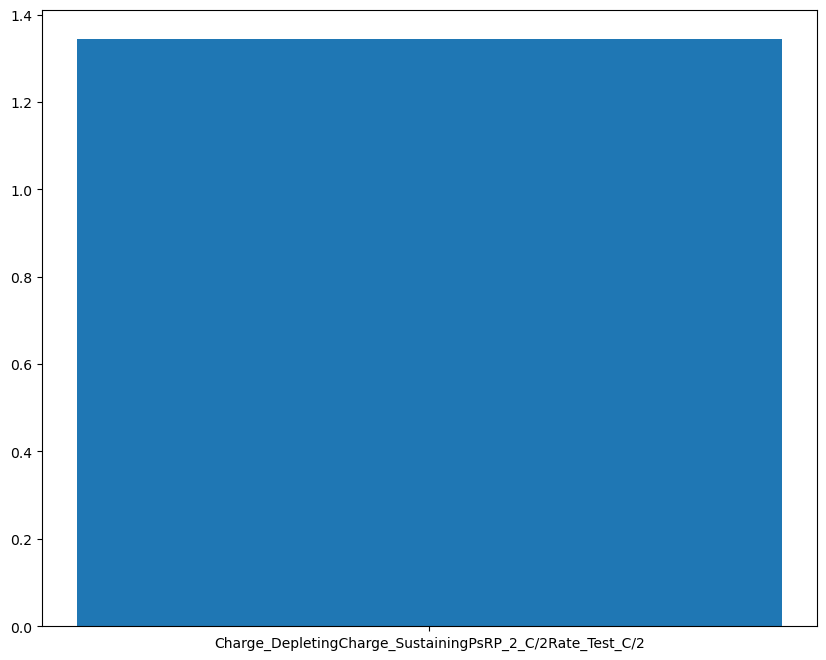

In [9]:
hdf2 = pd.HDFStore("../../data/data_for_ml_boundary_conditions.h5", mode="r")

C_boundary_conditions_charge_depleting = torch.load('../../results/neural_network/boundary_conditions/Charge_Depleting_C3 discharge capacity_C_model.pth')
C_boundary_conditions_charge_sustaining = torch.load('../../results/neural_network/boundary_conditions/Charge_Sustaining_C3 discharge capacity_C_model.pth')
C_boundary_conditions_PsRP2 = torch.load('../../results/neural_network/boundary_conditions/PsRP_2_C2_C3 discharge capacity_C_model.pth')
C_boundary_conditions_rate_test = torch.load('../../results/neural_network/boundary_conditions/Rate_Test_C2_C3 discharge capacity_C_model.pth')

# C_charge_depleting = torch.load('../../results/neural_network/boundary_conditions/no_boundary_Charge_Depleting_C3 discharge capacity_C_model.pth')
# C_charge_sustaining = torch.load('../../results/neural_network/boundary_conditions/no_boundary_Charge_Sustaining_C3 discharge capacity_C_model.pth')
# C_PsRP2 = torch.load('../../results/neural_network/boundary_conditions/no_boundary_PsRP_2_C2_C3 discharge capacity_C_model.pth')
# C_rate_test = torch.load('../../results/neural_network/boundary_conditions/no_boundary_Rate_Test_C2_C3 discharge capacity_C_model.pth')

#plot average mean squared error for each model
fig, ax = plt.subplots(figsize=(10, 8))

model_states = [
    C_boundary_conditions_charge_depleting,
    C_boundary_conditions_charge_sustaining,
    C_boundary_conditions_PsRP2,
    C_boundary_conditions_rate_test,
    # C_charge_depleting,
    # C_charge_sustaining,
    # C_PsRP2,
    # C_rate_test
]

titles = [
    ("Charge_Depleting", True),
    ("Charge_Sustaining", True),
    ("PsRP_2_C/2", True),
    ("Rate_Test_C/2", True),
    # ("Charge_Depleting", False),
    # ("Charge_Sustaining", False),
    # ("PsRP_2_C/2", False),
    # ("Rate_Test_C/2", False)
]


average_mses = []
for i, (model_state, (title, model_parameter_flag)) in enumerate(zip(model_states, titles)):
    df_all = hdf2.get(title.replace(" ", "_"))

    df = df_all[df_all["cell_id"].str.startswith("C_")].reset_index(drop=True)

    if title == "Charge_Depleting" or title == "Charge_Sustaining":
        df_train = df[df["split_type"] == "training"].reset_index(drop=True).groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
        df_test = df[df["split_type"] == "testing"].reset_index(drop=True)
        input_size = 4
    else:
        input_size = 5
        splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
        df = df.groupby("measurement_id").sample(frac=0.1, random_state=42).reset_index(drop=True)
        idx_train, idx_test = next(splitter.split(df, groups=df["measurement_id"]))
        df_train = df.iloc[idx_train].reset_index(drop=True)
        df_test = df.iloc[idx_test].reset_index(drop=True)
    
    if not model_parameter_flag:
        input_size = 3

    test_dataloader = DataLoader(DataFrameDataset(df_test, target="C/3 discharge capacity",key=title.replace(" ", "_"), num_features=input_size, transform=ToTensor()), batch_size=64, shuffle=False)

    model = BasicRNN(input_size=input_size, hidden_size=128, output_size=1)
    model.load_state_dict(model_state)
    model.eval()
    mse_losses = []
    criterion = nn.MSELoss()
    with torch.no_grad():
        for X, y in test_dataloader:
            outputs = model(X)
            loss = criterion(outputs, y)
            mse_losses.append(loss.item())
    average_mse = np.mean(mse_losses)
    average_mses.append(average_mse)
ax.bar(titles_no_flag, average_mses)
# ax.set_title(f"{title} - Average MSE: {average_mse:.4f}")

In [27]:
hdf2 = pd.HDFStore("../../data/data_raw.h5", mode="r")
keys = hdf2.keys()
df = hdf2.get(keys[0])

for segment_desc in df["Segment Description"].unique():
    hdf_segment = df[df["Segment Description"] == segment_desc].reset_index(drop=True)
    print( "Step: ", hdf_segment.iloc[0]['Step'], segment_desc, len(hdf_segment))

Step:  1 nan 3654
Step:  5 Equilibration cycle charge CC 6694
Step:  6 Equilibration cycle charge CV 53
Step:  7 Equilibration cycle after charge rest 180
Step:  8 Equilibration cycle discharge CC 6599
Step:  9 Equilibration cycle discharge CV 13
Step:  10 Equilibration cycle after discharge rest 180
Step:  11 Rate test C/10 cycle charge CC 21078
Step:  12 Rate test C/10 cycle charge CV 1
Step:  13 Rate test C/10 cycle after charge rest 180
Step:  14 Rate test C/10 cycle discharge CC 22223
Step:  15 Rate test C/10 cycle discharge CV 2
Step:  16 Rate test C/10 cycle after discharge rest 180
Step:  17 Rate test C/5 cycle charge CC 11376
Step:  18 Rate test C/5 cycle charge CV 16
Step:  19 Rate test C/5 cycle after charge rest 180
Step:  20 Rate test C/5 cycle discharge CC 10808
Step:  21 Rate test C/5 cycle discharge CV 5
Step:  22 Rate test C/5 cycle after discharge rest 180
Step:  23 Rate test C/3 cycle charge CC 6508
Step:  24 Rate test C/3 cycle charge CV 28
Step:  25 Rate test C/3 c

In [23]:
df

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
0,1.0,1,1,1,1,1,1.0,0.0,3.152,0.0,0.0,0.0,29.5,REST,6/25/2024 6:05:04 AM,,nan,NaN,NaN
1,2.0,1,1,1,1,1,2.0,0.0,3.152,0.0,0.0,0.0,30.0,REST,6/25/2024 6:05:05 AM,,nan,NaN,NaN
2,3.0,1,1,1,1,1,3.0,0.0,3.152,0.0,0.0,0.0,29.5,REST,6/25/2024 6:05:06 AM,,nan,NaN,NaN
3,4.0,1,1,1,1,1,4.0,0.0,3.152,0.0,0.0,0.0,30.0,REST,6/25/2024 6:05:07 AM,,nan,NaN,NaN
4,5.0,1,1,1,1,1,5.0,0.0,3.152,0.0,0.0,0.0,30.0,REST,6/25/2024 6:05:08 AM,,nan,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326358,493005.8,1,1,1,1,53,1760.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:17:44 PM,,nan,NaN,NaN
326359,493015.8,1,1,1,1,53,1770.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:17:54 PM,,nan,NaN,NaN
326360,493025.8,1,1,1,1,53,1780.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:18:04 PM,,nan,NaN,NaN
326361,493035.8,1,1,1,1,53,1790.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:18:14 PM,,nan,NaN,NaN


In [20]:
desc_list = df["Segment Description"].unique()

for segment_desc in desc_list:
    hdf_segment = df[df["Segment Description"] == segment_desc].reset_index(drop=True)
    print( "Step: ", hdf_segment.iloc[0]['Step'], segment_desc, len(hdf_segment))

KeyError: 'Segment Description'